In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [8]:
auto = pd.read_csv("Auto.csv")
display(auto.head(10))
display(auto.shape)

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino
5,15.0,8,429.0,198,4341,10.0,70,1,ford galaxie 500
6,14.0,8,454.0,220,4354,9.0,70,1,chevrolet impala
7,14.0,8,440.0,215,4312,8.5,70,1,plymouth fury iii
8,14.0,8,455.0,225,4425,10.0,70,1,pontiac catalina
9,15.0,8,390.0,190,3850,8.5,70,1,amc ambassador dpl


(392, 9)

In [5]:
auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64
name             object
dtype: object

In [38]:
auto.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
origin,392.0,1.576531,0.805518,1.0,1.000,1.00,2.000,3.0


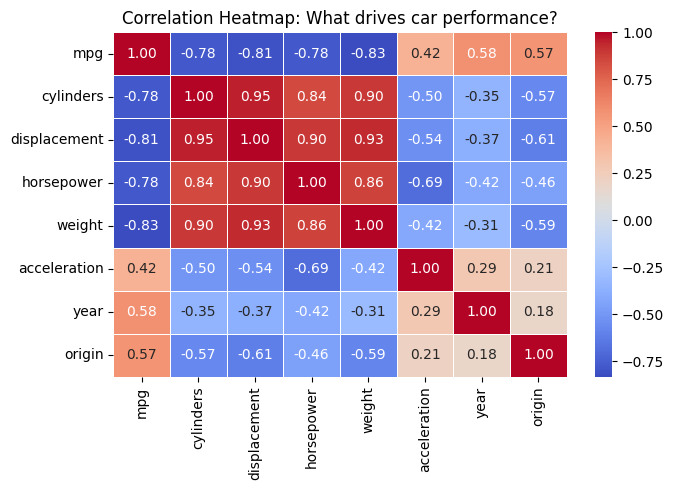

In [49]:
# 1. Calculate the correlations (only for numerical columns)
# .corr() calculates a score from -1 to 1 for every pair of columns
corr_matrix = auto.select_dtypes(include=['number']).corr()

# 2. Create the figure and axis
fig, ax = plt.subplots(figsize=(7, 5))

# 3. Create the heatmap
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap: What drives car performance?')

plt.tight_layout()
plt.show()

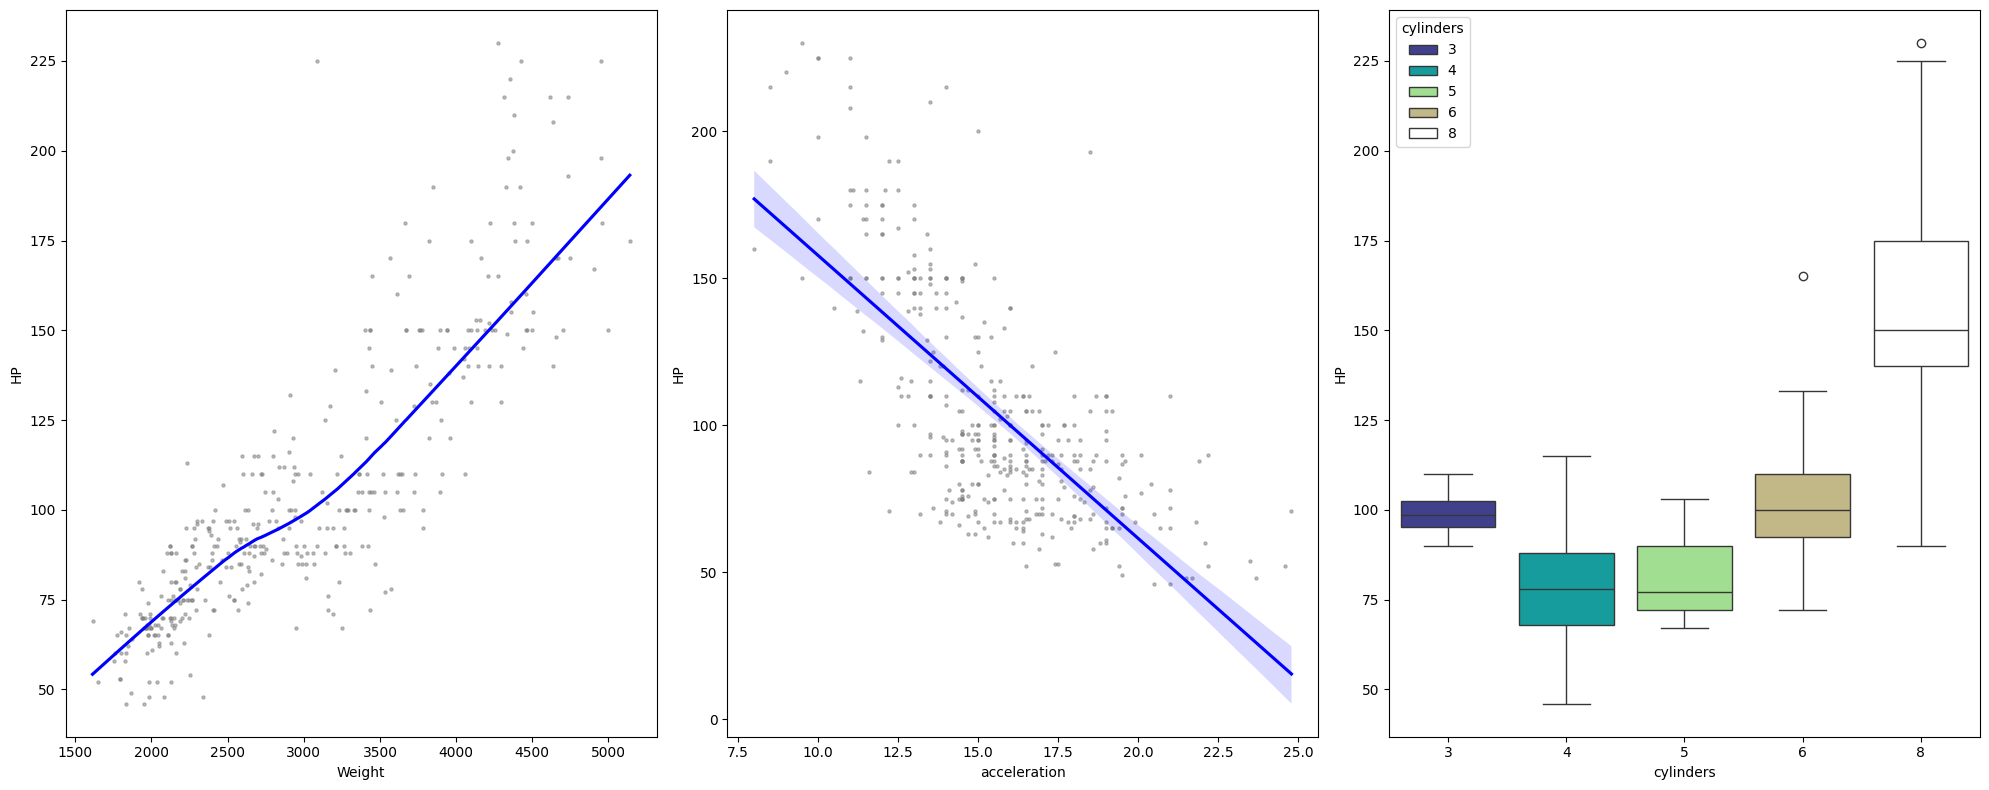

In [48]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Plot 1: 'lowess=True' creates that smooth, non-linear blue line
sns.regplot(x='weight', y='horsepower', data=auto, ax=axes[0], 
            scatter_kws={'color': 'gray', 's': 5, 'alpha': 0.5}, 
            line_kws={'color': 'blue'}, lowess=True)
axes[0].set_xlabel('Weight')
axes[0].set_ylabel('HP')

# Plot 2
sns.regplot(x='acceleration', y='horsepower', data=auto, ax=axes[1], 
            scatter_kws={'color': 'gray', 's': 5, 'alpha': 0.5}, 
            line_kws={'color': 'blue'})
axes[1].set_xlabel('acceleration')
axes[1].set_ylabel('HP')

# Plot 3
sns.boxplot(x='cylinders', y='horsepower', hue='cylinders', data=auto, ax=axes[2], 
            palette='terrain')
axes[2].set_xlabel('cylinders')
axes[2].set_ylabel('HP')

plt.tight_layout()
plt.show()

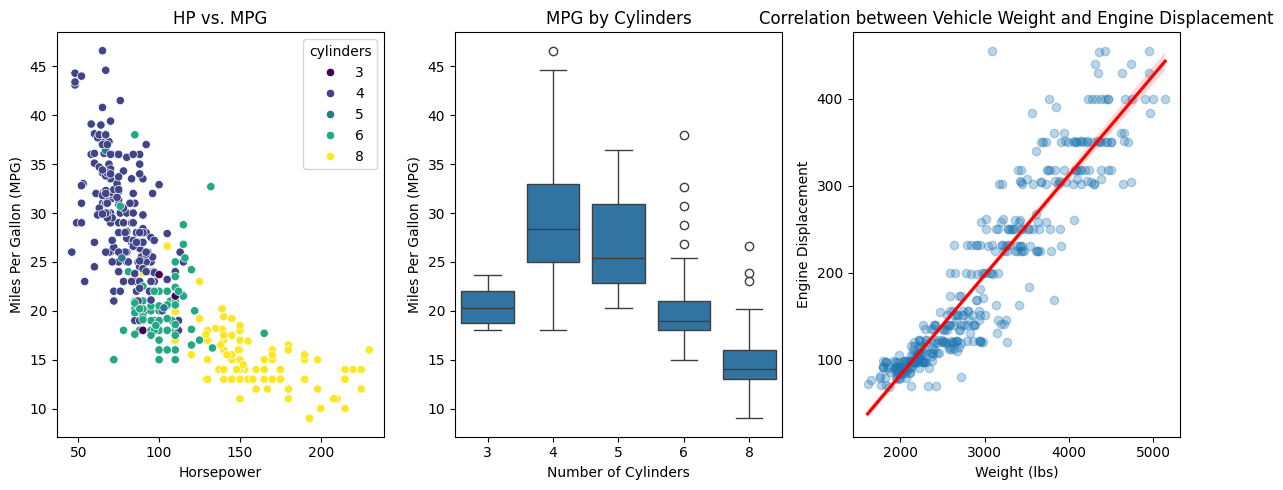

In [41]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))

# 2. First Plot: Scatterplot on ax[0] (the left side)
sns.scatterplot(data=auto, x='horsepower', y='mpg', hue='cylinders', palette='viridis', ax=ax[0])
ax[0].set_title('HP vs. MPG')
ax[0].set_xlabel('Horsepower')
ax[0].set_ylabel('Miles Per Gallon (MPG)')

# 3. Second Plot: Boxplot on ax[1] (the right side)
sns.boxplot(data=auto, x='cylinders', y='mpg', ax=ax[1])
ax[1].set_title('MPG by Cylinders')
ax[1].set_xlabel('Number of Cylinders')
ax[1].set_ylabel('Miles Per Gallon (MPG)')

sns.regplot(data=auto, x='weight', y='displacement', 
            scatter_kws={'alpha':0.3}, line_kws={'color':'red'}, ax=ax[2])

ax[2].set_title('Correlation between Vehicle Weight and Engine Displacement')
ax[2].set_xlabel('Weight (lbs)')
ax[2].set_ylabel('Engine Displacement')

# 4. Clean up the spacing so labels don't overlap
plt.tight_layout()
plt.show()

In [7]:
wage = pd.read_csv("Wage.csv")
wage.head(10)

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154
5,2008,54,2. Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.845098,127.115744
6,2009,44,2. Married,4. Other,3. Some College,2. Middle Atlantic,1. Industrial,2. >=Very Good,1. Yes,5.133021,169.528538
7,2008,30,1. Never Married,3. Asian,3. Some College,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.716003,111.720849
8,2006,41,1. Never Married,2. Black,3. Some College,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.778151,118.884359
9,2004,52,2. Married,1. White,2. HS Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,4.857332,128.680488


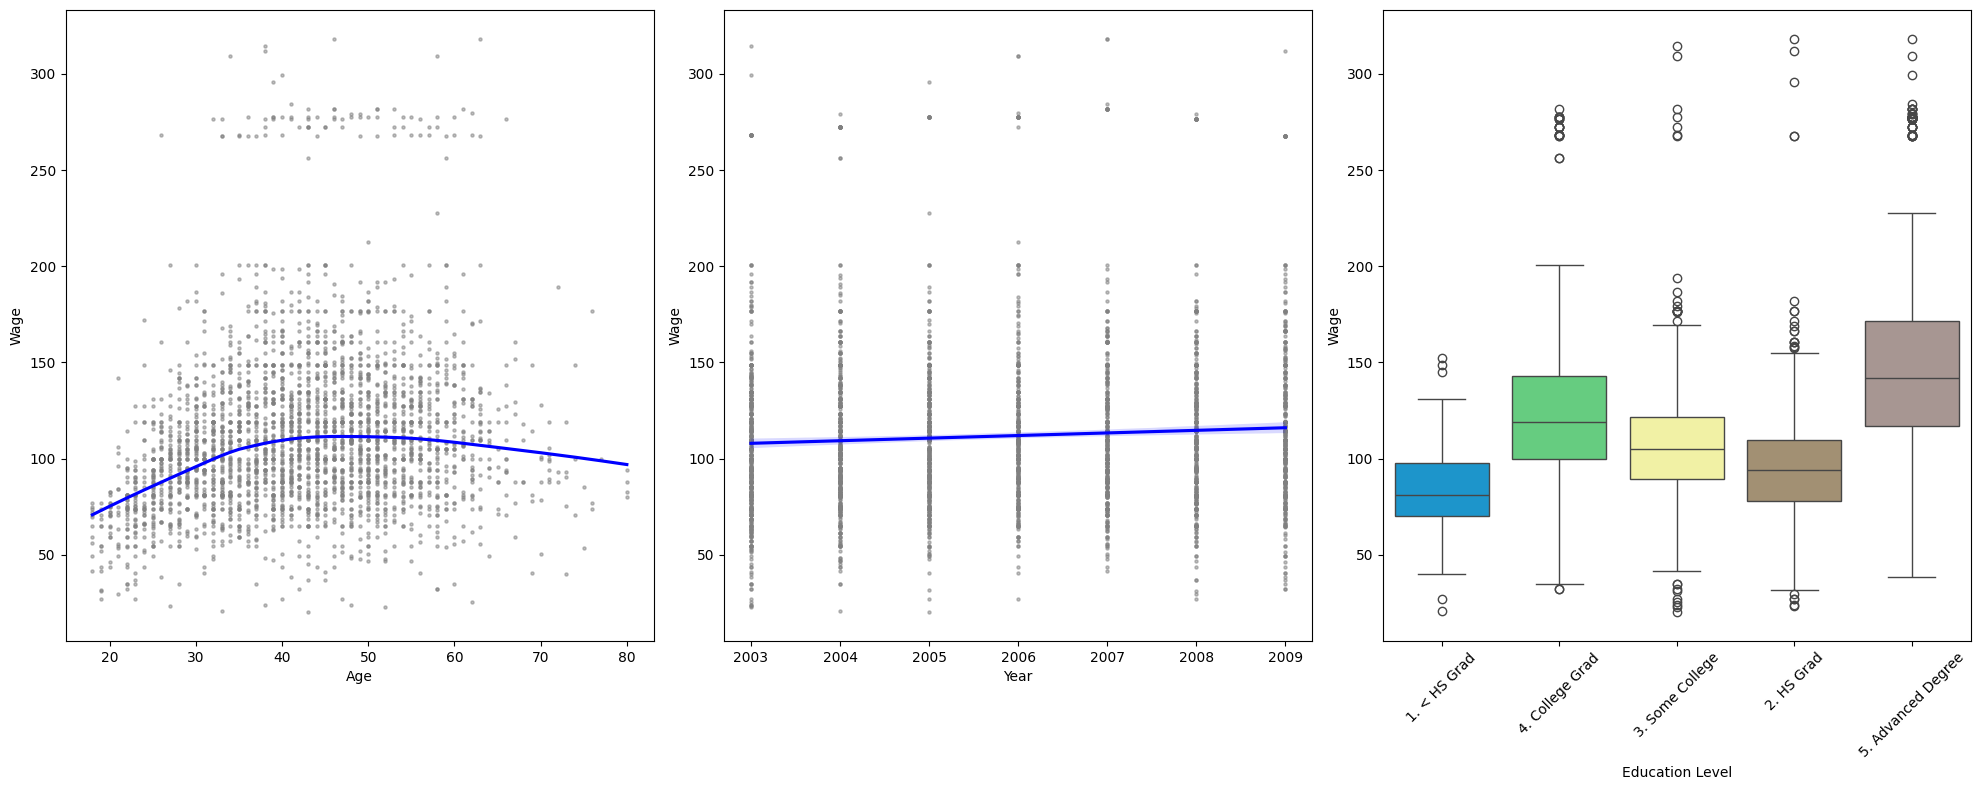

In [26]:
# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

# Plot 1: Age vs Wage
# 'lowess=True' creates that smooth, non-linear blue line
sns.regplot(x='age', y='wage', data=wage, ax=axes[0], 
            scatter_kws={'color': 'gray', 's': 5, 'alpha': 0.5}, 
            line_kws={'color': 'blue'}, lowess=True)
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Wage')

# Plot 2: Year vs Wage
sns.regplot(x='year', y='wage', data=wage, ax=axes[1], 
            scatter_kws={'color': 'gray', 's': 5, 'alpha': 0.5}, 
            line_kws={'color': 'blue'})
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Wage')

# Plot 3: Education vs Wage
# We use 'hue' to get the different colors seen in the book
sns.boxplot(x='education', y='wage', hue='education', data=wage, ax=axes[2], 
            palette='terrain', legend=False)
axes[2].set_xlabel('Education Level')
axes[2].set_ylabel('Wage')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()